In [3]:
sites = ["GAGGTAAAC", "TCCGTAAGC", "CAGGTTGGA", "ACAGTCAGC", "TAGGTCAGC", "CAGGTCAGC", "CAGGTCGAT", "CAGGTCAGC", "CAGGTCAGC", "CAGGTTGGC"]

### Задание 4.

In [15]:
import Bio as bp
from Bio import motifs
from Bio.Seq import Seq
from Bio import SeqIO
import random
import matplotlib.pyplot as plt
import numpy as np

In [17]:
sequences = [Seq(site) for site in sites]
motif = motifs.create(sequences)
ppm = motif.counts.normalize(pseudocounts=0.1)

In [27]:
probs = np.array([[ppm[base][i] for i in range(ppm.length)] for base in 'ACGT'])
entropies = -np.nansum(probs * np.log2(probs, where=probs>0), axis=0)
ICs = 2 - entropies

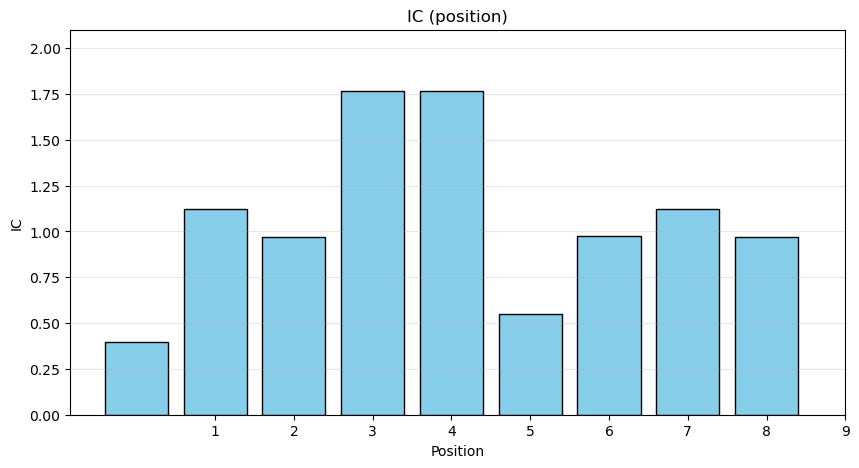

In [45]:
pos = np.arange(0, len(IC))

plt.figure(figsize=(10,5))
plt.bar(pos, IC, color='skyblue', edgecolor='black')
plt.xlabel('Position')
plt.ylabel('IС')
plt.title('IС (position)')
plt.xticks(positions)
plt.ylim(0, 2.1)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [47]:
print(f"PFM - матрица частот: \n{motif.counts}")

PFM - матрица частот: 
        0      1      2      3      4      5      6      7      8
A:   1.00   8.00   1.00   0.00   0.00   2.00   7.00   2.00   1.00
C:   6.00   2.00   1.00   0.00   0.00   6.00   0.00   0.00   8.00
G:   1.00   0.00   8.00  10.00   0.00   0.00   3.00   8.00   0.00
T:   2.00   0.00   0.00   0.00  10.00   2.00   0.00   0.00   1.00



**Вывод:** кор-мотивами являются в первую очередь позиции 3 и 4. Видно по PFM и диаграмме, что информация о позициях, для которых (почти) всегда наблюдался один остток - максимальна (как в случае 3 и 4, а также, например, 1 и 7). При увеличении рандомности остатков (увеличении энтропии) информация падает (например, позиции 0 и 5.